# Flat and two-layer LMDP walkthrough

This notebook follows the implementation from the physical maze to the exact flat solution and then the two-layer multitask model. All examples use the canonical parameters and fixed random seeds.

In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from andrew_mlmdp import (
    Maze,
    ModelParameters,
    build_subgoal_passive_dynamics,
    build_two_layer_model,
    compute_layer_one_plan,
    controlled_dynamics,
    desirability_grid,
    plot_controlled_dynamics,
    plot_subgoal_passive_dynamics,
    plot_trajectory,
    sample_hierarchical_rollout,
    sample_rollout,
    solve_desirability,
)

## Canonical configuration

These are project defaults rather than values uniquely fixed by the paper.

In [ ]:
parameters = ModelParameters(control_cost=.2)
maze = Maze.from_file(PROJECT_ROOT / 'mazes' / 'four_rooms.txt')
goal = (10, 9)

print(parameters)
print(f'maze shape: {maze.shape}')
print(f'free states: {len(maze.free_cells)}')
print(f'goal state: {maze.state_index(goal)}')

ModelParameters(interior_reward=-0.1, goal_reward=1.0, control_cost=0.3, alpha=1.0, off_target_reward=-2.0, beta=10.0)
maze shape: (11, 11)
free states: 97
goal state: 95


## Exact flat first-exit LMDP

`solve_desirability` constructs and solves Equation 4. The vector follows `maze.free_cells` order and includes the terminal goal value.

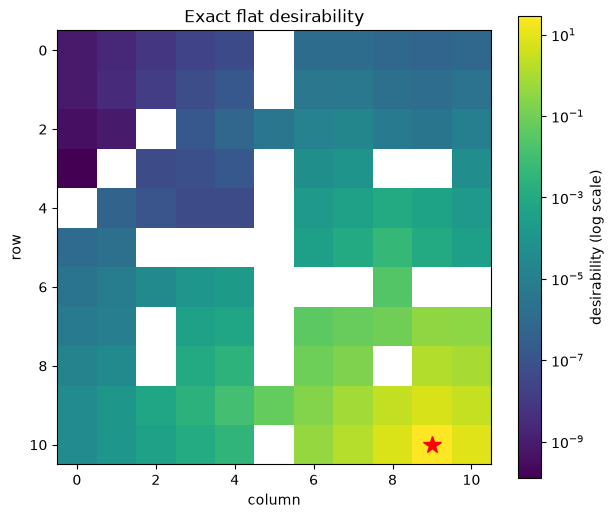

In [15]:
flat_desirability = solve_desirability(
    maze,
    goal,
    parameters=parameters,
)
flat_grid = desirability_grid(maze, flat_desirability)
positive = flat_grid[np.isfinite(flat_grid) & (flat_grid > 0.0)]

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    flat_grid,
    cmap='viridis',
    norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
)
ax.plot(goal[1], goal[0], marker='*', color='red', markersize=13)
ax.set(title='Exact flat desirability', xlabel='column', ylabel='row')
fig.colorbar(image, ax=ax, label='desirability (log scale)')
plt.show()

### Controlled dynamics and a seeded rollout

Equation 6 reweights each passive next-state probability by the desirability of that next state.

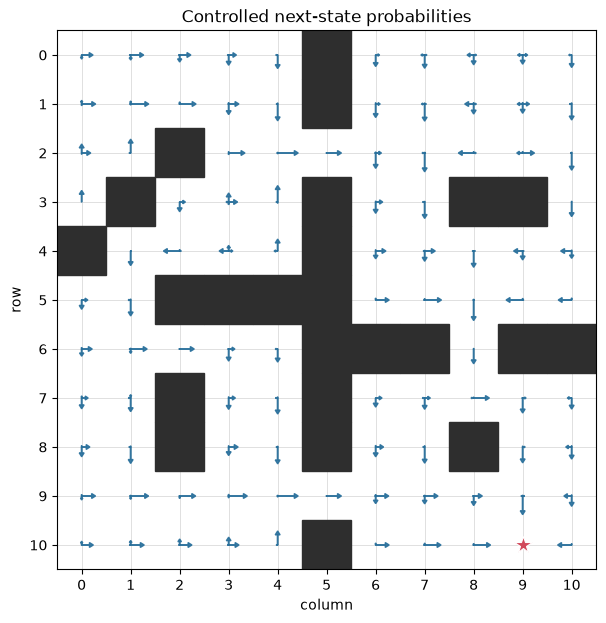

In [16]:
flat_controlled = controlled_dynamics(maze, flat_desirability)
plot_controlled_dynamics(maze, flat_controlled, goal=goal)
plt.show()

reached goal: True
physical steps: 30


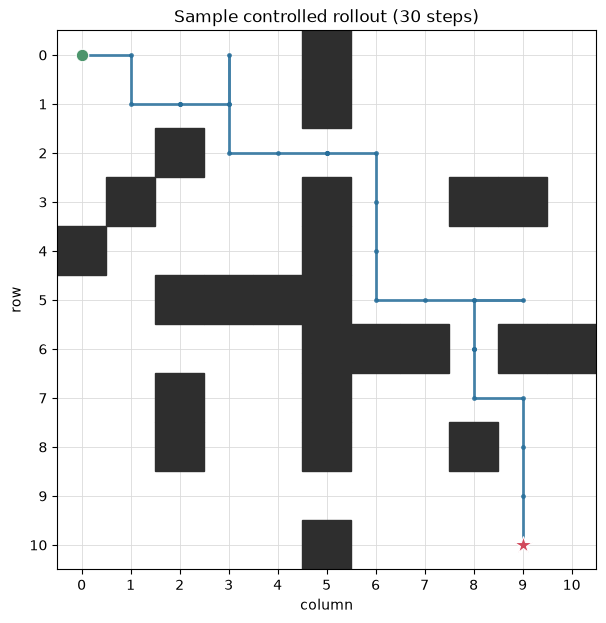

In [17]:
flat_start = (0, 0)
flat_rollout = sample_rollout(
    maze,
    flat_controlled,
    start=flat_start,
    goal=goal,
    seed=7,
)

print(f'reached goal: {flat_rollout[-1] == goal}')
print(f'physical steps: {len(flat_rollout) - 1}')
plot_trajectory(maze, flat_rollout, goal=goal)
plt.show()

## Two-layer multitask LMDP

The lower layer adds abstract boundary copies at A-F. First-hit probabilities through those copies induce the upper passive dynamics from Equations 8 and 9.

In [18]:
subgoal_labels = ('A', 'B', 'C', 'D', 'E', 'F')
subgoals = (
    (0, 0),
    (9, 2),
    (2, 3),
    (3, 7),
    (9, 7),
    (7, 9),
)
hierarchical_start = (1, 0)

### Task-independent upper passive graph

This is the square subgoal graph used for the Figure 3a-style view, before a current physical goal is added.

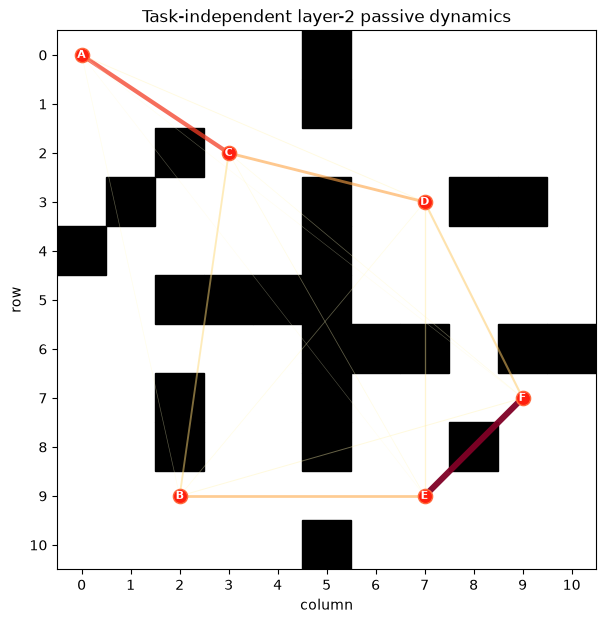

[[9.283e-01 2.500e-03 6.090e-02 7.100e-03 6.000e-04 6.000e-04]
 [2.500e-03 9.254e-01 2.300e-02 4.200e-03 3.680e-02 8.000e-03]
 [6.090e-02 2.300e-02 8.695e-01 3.880e-02 4.400e-03 3.400e-03]
 [7.100e-03 4.200e-03 3.880e-02 9.093e-01 1.340e-02 2.720e-02]
 [6.000e-04 3.680e-02 4.400e-03 1.340e-02 8.536e-01 9.120e-02]
 [6.000e-04 8.000e-03 3.400e-03 2.720e-02 9.120e-02 8.695e-01]]


In [19]:
subgoal_passive = build_subgoal_passive_dynamics(
    maze,
    subgoals,
    parameters=parameters,
)
fig, ax = plt.subplots(figsize=(7, 7))
plot_subgoal_passive_dynamics(
    maze,
    subgoals,
    subgoal_passive,
    labels=subgoal_labels,
    ax=ax,
)
plt.show()
print(np.round(subgoal_passive, 4))

### Goal-conditioned model

The model groups its arrays by meaning: lower first-exit dynamics, the multitask basis, and upper first-exit dynamics.

In [20]:
model = build_two_layer_model(
    maze,
    subgoals,
    goal,
    parameters=parameters,
)

print('target order:', subgoal_labels + ('goal',))
print('lower passive:', model.lower_dynamics.passive.shape)
print('boundary basis Q_b:', model.task_basis.boundary_desirability.shape)
print('interior basis Z_i:', model.task_basis.interior_desirability.shape)
print('upper passive:', model.upper_dynamics.passive.shape)

target order: ('A', 'B', 'C', 'D', 'E', 'F', 'goal')
lower passive: (103, 96)
boundary basis Q_b: (7, 7)
interior basis Z_i: (96, 7)
upper passive: (7, 6)


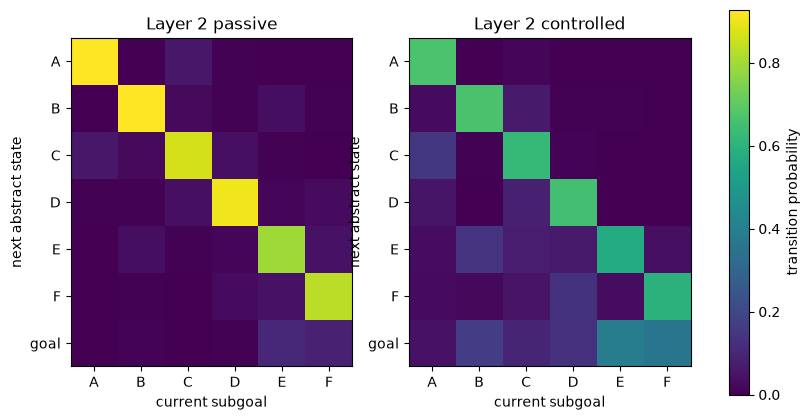

In [21]:
abstract_labels = subgoal_labels + ('goal',)
matrix_maximum = max(
    model.upper_dynamics.passive.max(),
    model.upper_controlled.max(),
)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, matrix, title in (
    (axes[0], model.upper_dynamics.passive, 'Layer 2 passive'),
    (axes[1], model.upper_controlled, 'Layer 2 controlled'),
):
    image = ax.imshow(
        matrix, cmap='viridis', vmin=0.0, vmax=matrix_maximum
    )
    ax.set_xticks(np.arange(len(subgoal_labels)), subgoal_labels)
    ax.set_yticks(np.arange(len(abstract_labels)), abstract_labels)
    ax.set(xlabel='current subgoal', ylabel='next abstract state', title=title)

fig.colorbar(image, ax=axes, label='transition probability')
plt.show()

### Reward inpainting and task composition

Equation 10 creates the subgoal reward signal. Equation 7 projects its exponentiated boundary values into the task basis.

In [22]:
initial_plan = compute_layer_one_plan(model, hierarchical_start)

print(' target   passive  controlled  reward    weight')
for label, passive, controlled, reward, weight in zip(
    abstract_labels,
    initial_plan.passive_abstract,
    initial_plan.controlled_abstract,
    initial_plan.inpainted_rewards,
    initial_plan.weights,
):
    print(
        f' {label:>4}    {passive:7.3f}     {controlled:7.3f}'
        f'    {reward:7.3f}   {weight:7.3f}'
    )

 target   passive  controlled  reward    weight
    A      0.786       0.361     -4.248     0.000
    B      0.007       0.049      0.414     0.142
    C      0.182       0.289      1.068     1.253
    D      0.021       0.099      0.779     0.478
    E      0.001       0.060      0.581     0.247
    F      0.002       0.054      0.525     0.205
 goal      0.000       0.089      1.000     1.000


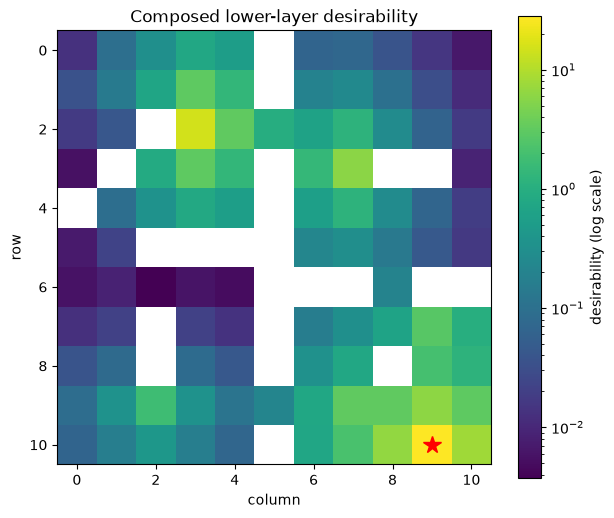

In [23]:
composed_grid = desirability_grid(
    maze, initial_plan.physical_desirability
)
positive = composed_grid[
    np.isfinite(composed_grid) & (composed_grid > 0.0)
]
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    composed_grid,
    cmap='viridis',
    norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
)
ax.plot(goal[1], goal[0], marker='*', color='red', markersize=13)
ax.set(title='Composed lower-layer desirability', xlabel='column', ylabel='row')
fig.colorbar(image, ax=ax, label='desirability (log scale)')
plt.show()

### Seeded hierarchical rollout

Subgoal-copy accesses update the active task blend without consuming physical time.

status: reached_goal
physical steps: 45
zero-time accesses: [(2, 3), (3, 7), (2, 3), (3, 7), (7, 9)]


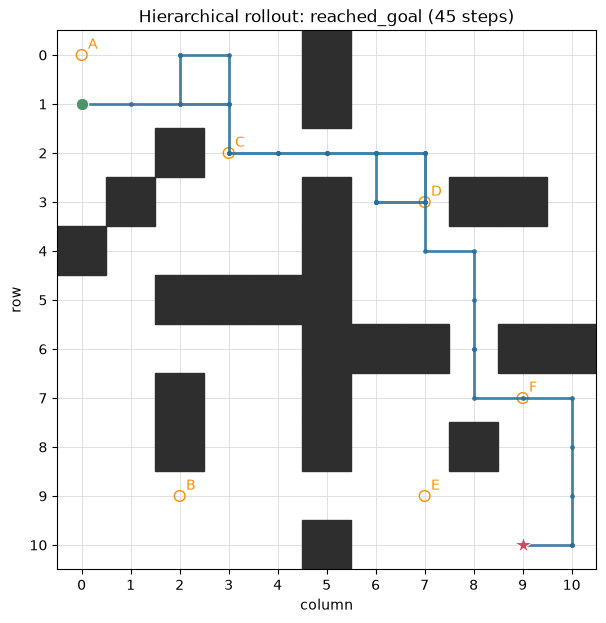

In [24]:
hierarchical_rollout = sample_hierarchical_rollout(
    model,
    hierarchical_start,
    seed=28,
)

print('status:', hierarchical_rollout.status)
print('physical steps:', hierarchical_rollout.physical_steps)
print('zero-time accesses:', hierarchical_rollout.subgoal_accesses)

ax = plot_trajectory(
    maze, hierarchical_rollout.trajectory, goal=goal
)
for label, (row, column) in zip(subgoal_labels, subgoals):
    ax.scatter(
        column, row, s=60, facecolors='none', edgecolors='darkorange'
    )
    ax.text(column + 0.13, row - 0.13, label, color='darkorange')
ax.set_title(
    f'Hierarchical rollout: {hierarchical_rollout.status} '
    f'({hierarchical_rollout.physical_steps} steps)'
)
plt.show()